# CDS hazard calibration and credit legs

Bootstrap survival from a spread strip, price a quarterly CDS, and reconcile premium and protection legs.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A credit desk needs more than the approximation spread ≈ loss-given-default × hazard. A CDS curve must reproduce quoted contracts under declared premium, default and settlement conventions.

This notebook constructs illustrative 1Y, 3Y and 5Y spreads of 80, 110 and 140 bp with recovery 40%, then uses `SpreadCdsHelper` and `PiecewiseFlatHazardRate`. The discount curve is the collection's OIS fixture. Helpers use zero settlement days, quarterly premiums, Following, Forward schedule generation and Actual/360. Helper implied quotes must match the input strip within $10^{-8}$ decimal rate units. Survival must remain between zero and one and decrease with maturity.

Next, `CreditDefaultSwap` and `MidPointCdsEngine` value a separate five-year protection-buyer ticket with running premium 100 bp, notional 100, protection starting on the reference date, quarterly Forward schedule, Actual/360, premium accrued on default, payment at default, no accrual rebate and zero cash-settlement days. It is intentionally an off-market ticket, not an assertion that its conventions equal every calibration-helper convention. The notebook independently sums survival-weighted premiums, accrued premium at midpoint default and loss-given-default payments; it then reprices the ticket at its own fair spread.

Midpoint default integration is a numerical approximation. This example is not an ISDA Standard Model validation and uses neither standard IMM contracts nor observed credit quotes. Hazard is a pricing-measure input, not a physical default forecast. References: [QuantLib Python CDS example](https://github.com/lballabio/QuantLib-SWIG/blob/master/Python/examples/cds.py), [midpoint engine](https://github.com/lballabio/QuantLib/blob/master/ql/pricingengines/credit/midpointcdsengine.cpp), and [ISDA model](https://www.cdsmodel.com/).

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
with valuation_date():
    discount, _, _ = curves()
    discount_handle = ql.YieldTermStructureHandle(discount)
    recovery, notional, running = .40, 100., .01
    tenors, spreads = [1, 3, 5], [.008, .011, .014]
    helpers = [ql.SpreadCdsHelper(s, ql.Period(y, ql.Years), 0, CAL,
               ql.Quarterly, ql.Following, ql.DateGeneration.Forward,
               ql.Actual360(), recovery, discount_handle)
               for y, s in zip(tenors, spreads)]
    hazard_curve = ql.PiecewiseFlatHazardRate(DATE, helpers, ql.Actual365Fixed())
    probability = ql.DefaultProbabilityTermStructureHandle(hazard_curve)
    # Trigger the lazy bootstrap before asking helpers for implied quotes.
    hazard_curve.survivalProbability(DATE + ql.Period('5Y'))
    calibration = pd.DataFrame({'tenor_years':tenors, 'input_bp':1e4*np.array(spreads),
                               'implied_bp':[1e4*h.impliedQuote() for h in helpers]})
    assert np.max(np.abs(calibration.input_bp-calibration.implied_bp)) < 1e-4
    schedule = ql.Schedule(DATE, DATE+ql.Period('5Y'), ql.Period('3M'), CAL,
                           ql.Following, ql.Following, ql.DateGeneration.Forward, False)
    def contract(spread):
        instrument = ql.CreditDefaultSwap(ql.Protection.Buyer, notional, spread,
            schedule, ql.Following, ql.Actual360(), True, True, DATE,
            ql.FaceValueClaim(), ql.Actual360(), False, DATE, 0)
        instrument.setPricingEngine(ql.MidPointCdsEngine(probability, recovery, discount_handle))
        return instrument
    cds = contract(running)
    rows = []
    for flow in cds.coupons():
        coupon = ql.as_coupon(flow)
        start, end, pay = coupon.accrualStartDate(), coupon.accrualEndDate(), coupon.date()
        midpoint = start + (end-start)//2
        dp = hazard_curve.survivalProbability(start)-hazard_curve.survivalProbability(end)
        scheduled = (notional*running*ql.Actual360().yearFraction(start,end)
                     *hazard_curve.survivalProbability(pay)*discount.discount(pay))
        accrued = (notional*running*ql.Actual360().yearFraction(start,midpoint)
                   *dp*discount.discount(midpoint))
        protection = notional*(1-recovery)*dp*discount.discount(midpoint)
        rows.append({'payment':pay.ISO(), 'scheduled_premium_PV':scheduled,
                     'default_accrual_PV':accrued, 'protection_PV':protection})
    legs = pd.DataFrame(rows)
    premium = legs.scheduled_premium_PV.sum()+legs.default_accrual_PV.sum()
    protection = legs.protection_PV.sum()
    assert abs(-premium-cds.couponLegNPV()) < 1e-10
    assert abs(protection-cds.defaultLegNPV()) < 1e-10
    assert abs(protection-premium-cds.NPV()) < 1e-10
    assert abs(contract(cds.fairSpread()).NPV()) < 1e-10
    survival = pd.DataFrame([{'years':y, 'survival':hazard_curve.survivalProbability(DATE+ql.Period(y,ql.Years))}
                             for y in range(0,6)])
    assert ((survival.survival > 0)&(survival.survival <= 1)).all()
    assert (np.diff(survival.survival) <= 0).all()
    summary = pd.DataFrame([{'running_bp':running*1e4, 'fair_ticket_spread_bp':cds.fairSpread()*1e4,
                'buyer_PV':cds.NPV(), 'manual_PV':protection-premium,
                'premium_PV':premium, 'protection_PV':protection}])
display(calibration.round(6)); display(summary.round(6)); display(legs.round(6))

,tenor_years,input_bp,implied_bp
0,1,80.0,80.0
1,3,110.0,110.0
2,5,140.0,140.0


,running_bp,fair_ticket_spread_bp,buyer_PV,manual_PV,premium_PV,protection_PV
0,100.0,139.911772,1.758672,1.758672,4.4064,6.165073


,payment,scheduled_premium_PV,default_accrual_PV,protection_PV
0,2026-12-15,0.249570,0.000415,0.199432
1,2027-03-15,0.243730,0.000406,0.194741
2,2027-06-15,0.245950,0.000419,0.196543
3,2027-09-15,0.242795,0.000413,0.194022
4,2027-12-15,0.236765,0.000624,0.299633
5,2028-03-15,0.233421,0.000615,0.295401
6,2028-06-15,0.232617,0.000627,0.294392
7,2028-09-15,0.229296,0.000618,0.290190
8,2028-12-15,0.223714,0.000590,0.283044
9,2029-03-15,0.218274,0.000575,0.276128


## Economic relationship

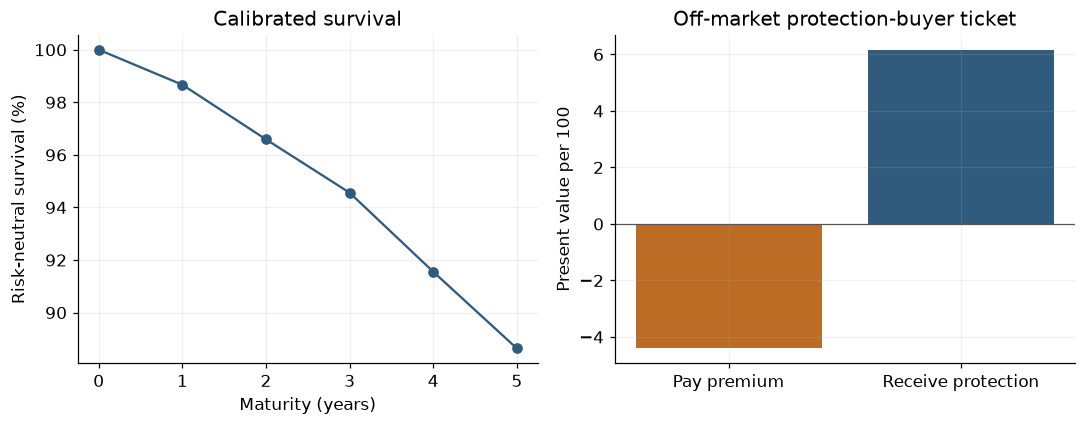

In [3]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].plot(survival.years, 100*survival.survival, marker='o', color='#315b7d')
axes[0].set(xlabel='Maturity (years)', ylabel='Risk-neutral survival (%)', title='Calibrated survival')
axes[1].bar(['Pay premium','Receive protection'], [-premium,protection], color=['#bc6c25','#315b7d'])
axes[1].axhline(0,color='#555555',lw=.8)
axes[1].set(ylabel='Present value per 100', title='Off-market protection-buyer ticket')
fig.tight_layout(); plt.show()

## Interpretation

The spread helpers reprice, survival is valid, and independently summed midpoint cash flows reproduce QuantLib's two legs and total PV. The ticket's fair spread belongs to its stated contract conventions; it is not automatically the five-year helper quote.